In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import r2_score, mean_squared_error
import math

In [59]:
diabetes = datasets.load_diabetes(as_frame=True)
diabetes_df = diabetes.data
target_df = diabetes.target

diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [60]:
X_train = diabetes_df[diabetes_df.index <= 361]
y_train = target_df[target_df.index <= 361]

X_test = diabetes_df[diabetes_df.index > 361]
y_test = target_df[target_df.index > 361]

In [61]:
linear_reg = linear_model.LinearRegression()
linear_reg.fit(X_train, y_train)

print("[w1, ... w_n] = ", linear_reg.coef_)
print("w0 = ", linear_reg.intercept_)



[w1, ... w_n] =  [   3.92718202 -253.94486874  520.35846552  300.42819747 -603.58774264
  325.27121483   10.78855295  139.51168049  669.05351038  111.45789687]
w0 =  152.73013266423447


In [62]:
ridge_reg = linear_model.Ridge(alpha=0.1)
ridge_reg.fit(X_train, y_train)

print("[w1, ... w_n] = ", ridge_reg.coef_)
print("w0 = ", ridge_reg.intercept_)

[w1, ... w_n] =  [  13.49869575 -218.29680002  477.84732119  277.83042387  -64.65653584
  -84.90778686 -194.49791984  110.59181132  421.20324478  125.31666478]
w0 =  152.72447168877036


In [63]:
print("True value: ", y_test.iloc[0])
print('LinearRegression prediction: ', linear_reg.predict(X_test.iloc[[0]]))
print('RidgeRegression prediction:', ridge_reg.predict(X_test.iloc[[0]]))

True value:  321.0
LinearRegression prediction:  [234.90685728]
RidgeRegression prediction: [227.26383499]


In [64]:
y_pred = linear_reg.predict(X_test)

s = pd.DataFrame()

s['y_true'] = y_test
s['y_pred'] = y_pred
s['error'] = abs(y_test - y_pred)

s

,y_true,y_pred,error
362,321.0,234.906857,86.093143
363,58.0,163.458562,105.458562
364,262.0,163.570686,98.429314
365,206.0,167.786320,38.213680
366,233.0,254.211062,21.211062
...,...,...,...
437,178.0,191.809194,13.809194
438,104.0,104.524821,0.524821
439,132.0,123.525247,8.474753
440,220.0,209.998994,10.001006


In [65]:
_lambda = [0, 0.0001,0.01, 0.04, 0.05, 0.06, 0.1, 0.5, 1, 5, 10, 20]

for a_lambda in _lambda:
    regression_regr = linear_model.Ridge(alpha = a_lambda, max_iter=1000)
    regression_regr.fit(X_train, y_train)
    diabetes_y_pred_redge = regression_regr.predict(X_test)
    print('Lambda = ' + str(a_lambda) + '; RMSE = ' +str(math.sqrt(mean_squared_error(y_test, diabetes_y_pred_redge))))

Lambda = 0; RMSE = 51.64223751435311
Lambda = 0.0001; RMSE = 51.649078311098904
Lambda = 0.01; RMSE = 51.97229255925035
Lambda = 0.04; RMSE = 52.179952000788646
Lambda = 0.05; RMSE = 52.217736616614076
Lambda = 0.06; RMSE = 52.25370884439912
Lambda = 0.1; RMSE = 52.403451674107785
Lambda = 0.5; RMSE = 54.63916408668823
Lambda = 1; RMSE = 57.40001081961914
Lambda = 5; RMSE = 67.25395495013551
Lambda = 10; RMSE = 71.19593942174217
Lambda = 20; RMSE = 74.06221030868194


count     80.00000
mean     152.38750
std       78.46994
min       40.00000
25%       72.00000
50%      140.00000
75%      217.50000
max      321.00000
Name: target, dtype: float64

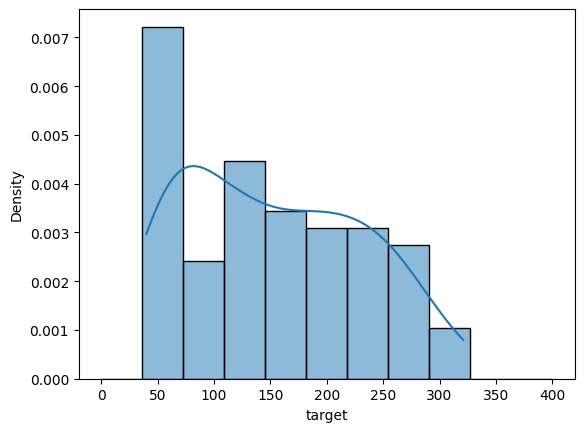

In [ ]:
sns.histplot(y_test, kde=True, stat='density', binrange=(0, 400))
y_test.describe()

,0
count,80.000000
mean,155.683983
std,57.524381
min,48.856697
25%,112.488730
50%,160.724844
75%,190.677729
max,279.787777


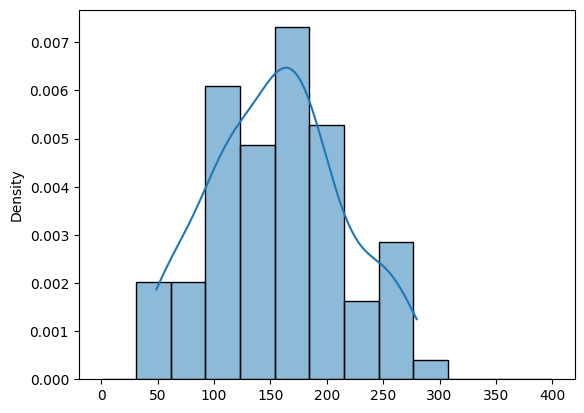

In [78]:
sns.histplot(y_pred, kde=True, stat='density', binrange=(0, 400))
pd.DataFrame(data=y_pred).describe()

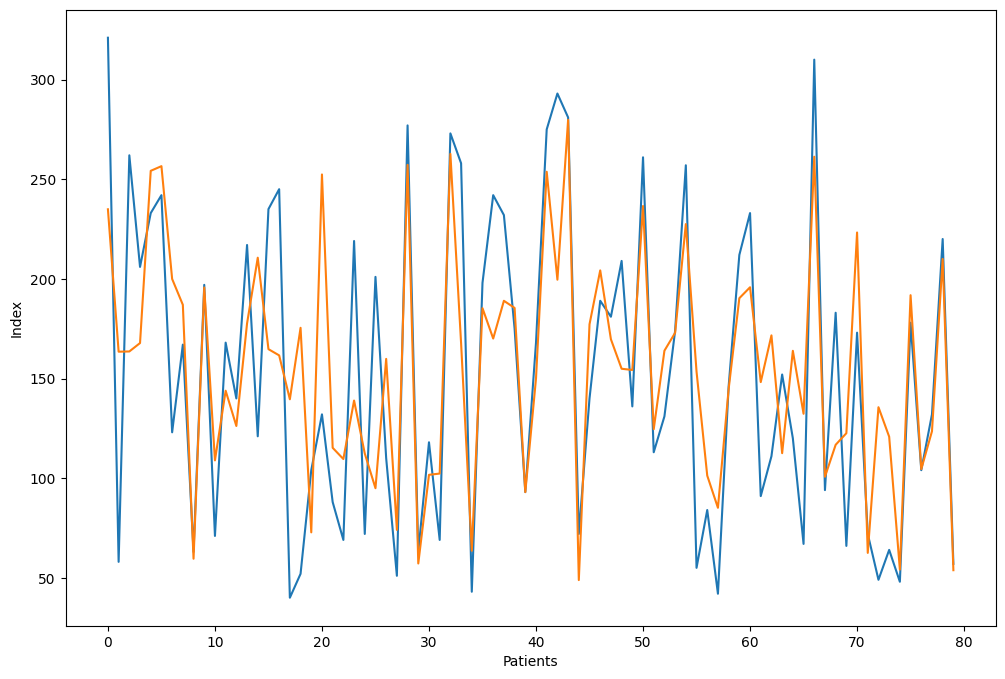

In [83]:
plt.figure(figsize=(12,8))
plt.plot(y_test.reset_index(drop=True))
plt.plot(y_pred)
 
plt.xlabel('Patients')

plt.ylabel('Index')
 
 
# function to show the plot
plt.show()